# 15 — SA, IRB and the Aggregate Output Floor

## Bringing the two approaches together

Both credit approaches and the non-credit RWA inputs are now complete. This notebook compares SA and IRB, then applies the aggregate output floor.

Final aggregate RWA is the larger of model aggregate RWA and the configured floor amount. It becomes the denominator used for capital adequacy.

### How to read the aggregate comparison

| Term | Simple meaning |
|---|---|
| Model aggregate RWA | IRB Credit RWA plus market and operational RWA |
| Standardised aggregate base | SA Credit RWA plus market and operational RWA |
| Output floor | a percentage of the standardised aggregate base |
| Binding | the floor exceeds model aggregate RWA and becomes final RWA |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


> Market and operational RWA used in the floor are synthetic configured inputs. Their amounts and real calculation routes were shown in notebook 14 before they are added here.

## Completed Credit RWA approaches by class

The paired bars compare two methods on the same synthetic loans. Standardised Approach RWA comes from prescribed weights. IRB RWA comes from risk parameters and capital functions.

The left chart uses a logarithmic money scale so smaller classes remain visible. The right chart divides each approach’s RWA by its own EAD. These are method-specific risk densities, not a comparison using one common exposure denominator.

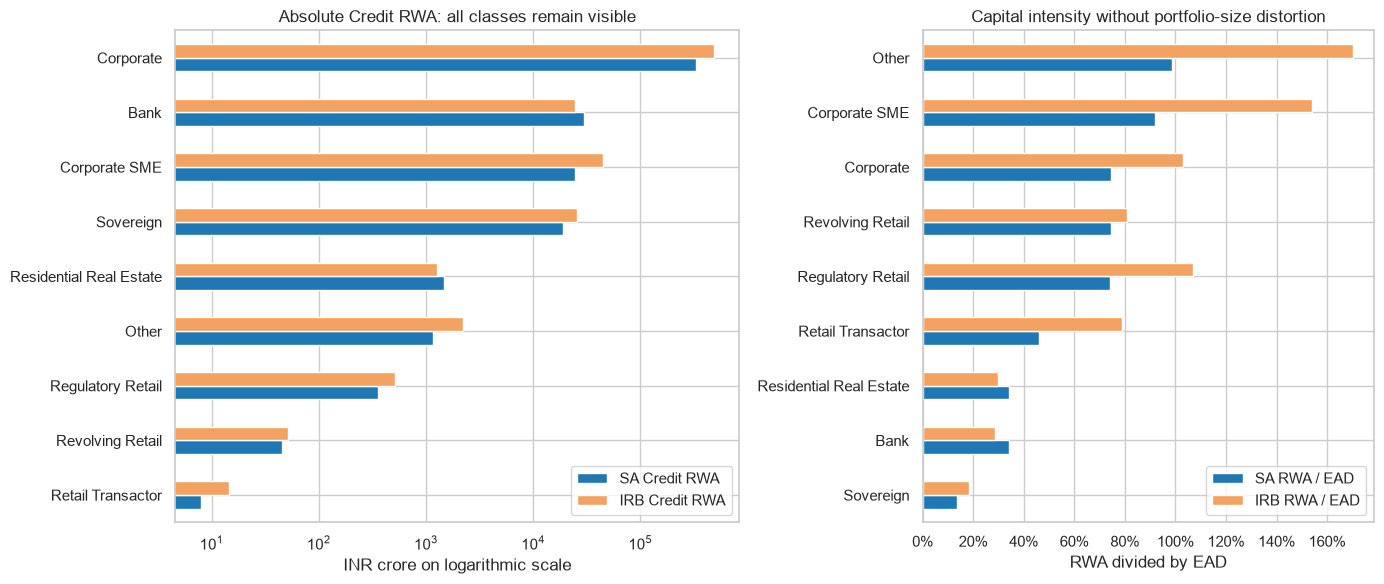

In [2]:
approach_comparison = loans.groupby("performing_exposure_class").agg(
    sa_rwa=("sa_rwa", "sum"),
    irb_rwa=("irb_rwa", "sum"),
).sort_values("sa_rwa") / CRORE

figure, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.25, 1]})
approach_comparison.plot.barh(ax=axes[0], color=[COLORS[1], COLORS[4]])
axes[0].set_xscale("log")
axes[0].set_xlabel("INR crore on logarithmic scale")
axes[0].set_ylabel("")
axes[0].set_title("Absolute Credit RWA: all classes remain visible")
axes[0].legend(["SA Credit RWA", "IRB Credit RWA"])

class_ead = loans.groupby("performing_exposure_class")[["ead_pre_crm", "ead_irb"]].sum() / CRORE
density = pd.DataFrame({
    "SA RWA / EAD": approach_comparison["sa_rwa"] / class_ead["ead_pre_crm"],
    "IRB RWA / EAD": approach_comparison["irb_rwa"] / class_ead["ead_irb"],
})
readable = lambda name: name.replace("_", " ").title().replace("Sme", "SME")
axes[0].set_yticklabels([readable(name) for name in approach_comparison.index])
density = density.rename(index=readable)
density.sort_values("SA RWA / EAD").plot.barh(ax=axes[1], color=[COLORS[1], COLORS[4]])
axes[1].set_xlabel("RWA divided by EAD")
axes[1].set_ylabel("")
axes[1].set_title("Capital intensity without portfolio-size distortion")
axes[1].xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.tight_layout()
plt.show()

A lower IRB bar does not mean the loan disappeared or necessarily became safer. The methods translate risk differently. The output floor limits the aggregate capital benefit from model-based RWA.

## Aggregate floor calculation

The table shows the complete bank-level comparison. The floor is not applied to each loan separately.

In [3]:
floor_table = pd.read_csv(ROOT / "outputs/tables/output_floor.csv")
base_floor = floor_table.loc[floor_table["scenario"].eq("base")].copy()
monetary = base_floor["metric"].ne("Output-floor rate")
base_floor.loc[monetary, "value"] /= CRORE
display(base_floor.rename(columns={"value": "Value (INR crore, except rate)"}))

,scenario,metric,"Value (INR crore, except rate)",floor_binding
0,base,SA Credit RWA,405323.359431,False
1,base,IRB Credit RWA,583349.232898,False
2,base,Standardised aggregate RWA base,430323.359431,False
3,base,Pre-floor model aggregate RWA,608349.232898,False
4,base,Output-floor rate,0.650000,False
5,base,Output-floor amount,279710.183630,False
6,base,Final aggregate RWA,608349.232898,False
7,base,Floor uplift,0.000000,False


Market and operational RWA appear in both sides of the comparison because capital adequacy covers all three major risk categories. The final aggregate amount is the larger result and is carried into capital ratios.